# Submission Akhir DLTM - Multivariate Multi-Horizon Time Series Forecasting

**Nama:** Dimas Tri M

**Dataset:** Multivariate Crypto Data Hourly (Bitcoin) - 2017 to 2023
---
**Penjelasan Capaian Kriteria:**
1. Menggunakan Custom Dropout, Custom Dense, Custom MHA pada Baseline dan Seq2Seq.
2. Seq2Seq menggunakan Model Subclassing dengan Teacher Forcing.
3. Custom Loss menggunakan Weighted Horizon.
4. Custom Callback untuk Reduce LR on Plateau dan Early Stopping.
5. Training menggunakan tf.GradientTape.


## 1. Setup dan Import Library

In [1]:
!pip install -q statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Memuat Dataset

In [4]:
btc_file = 'Bitcoin3.csv'
if os.path.exists(btc_file):
    df_raw = pd.read_csv(btc_file, on_bad_lines='skip')
    print(f'File yang dimuat: {btc_file}')
else:
    print(f'Error: File {btc_file} tidak ditemukan.')
    df_raw = pd.DataFrame()

File yang dimuat: Bitcoin3.csv


In [5]:
# Preprocessing awal
date_col = [c for c in df_raw.columns if c.lower() in ['date', 'datetime', 'time', 'timestamp']]
if date_col:
    df_raw[date_col[0]] = pd.to_datetime(df_raw[date_col[0]], errors='coerce')
    df_raw.dropna(subset=[date_col[0]], inplace=True)
    df_raw = df_raw.sort_values(date_col[0]).reset_index(drop=True)
    df_raw.set_index(date_col[0], inplace=True)

# Ambil kolom numerik
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
exclude_keywords = ['unix', 'timestamp']
numeric_cols = [c for c in numeric_cols if not any(kw in c.lower() for kw in exclude_keywords)]

df = df_raw[numeric_cols].copy()
df.dropna(inplace=True)
print(f'Shape data: {df.shape}')
df.head()

Shape data: (16666, 6)


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


## 3. Exploratory Data Analysis (EDA)

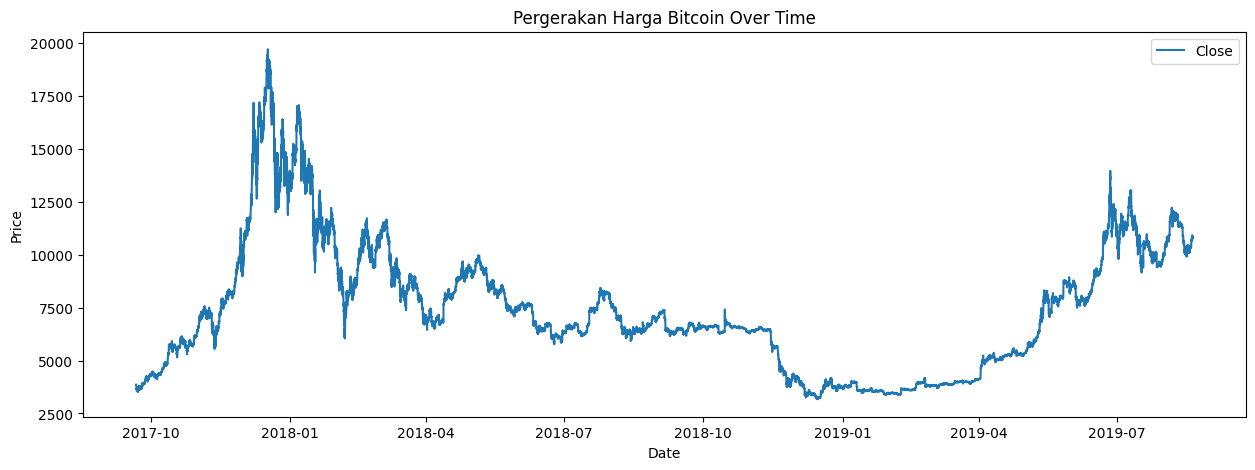

In [6]:
target_column = 'Close'
plt.figure(figsize=(15, 5))
plt.plot(df.index, df[target_column], label=target_column)
plt.title('Pergerakan Harga Bitcoin Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

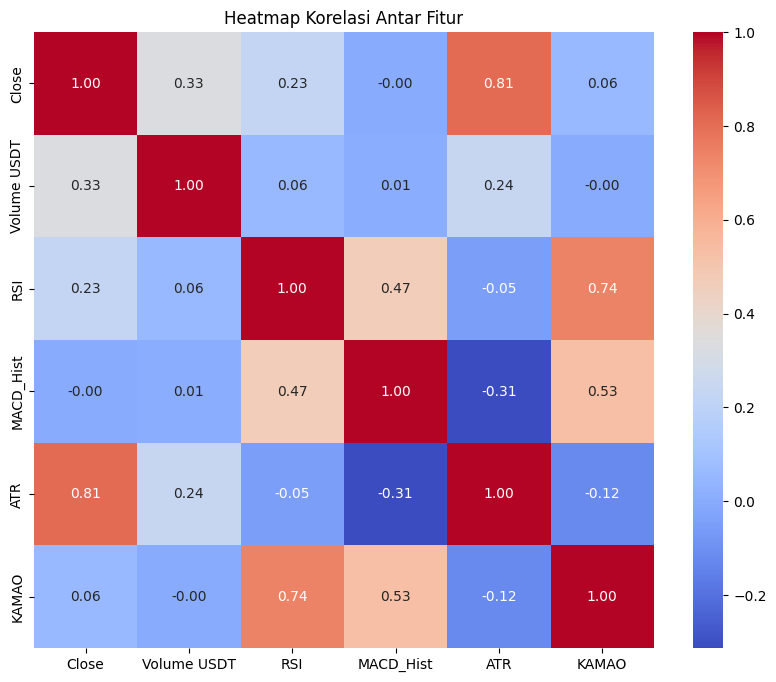

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

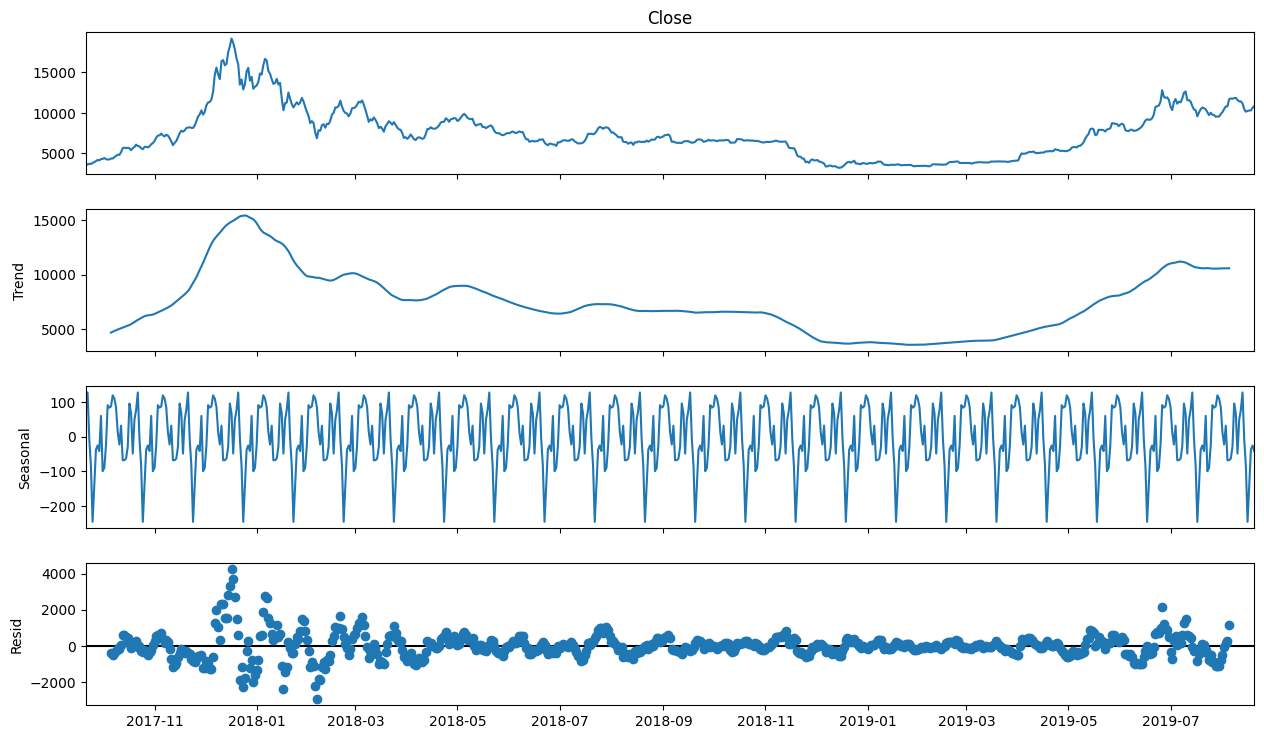

In [8]:
# Analisis Dekomposisi
decomp_data = df[target_column].resample('D').mean().ffill()

decomposition = seasonal_decompose(decomp_data, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()


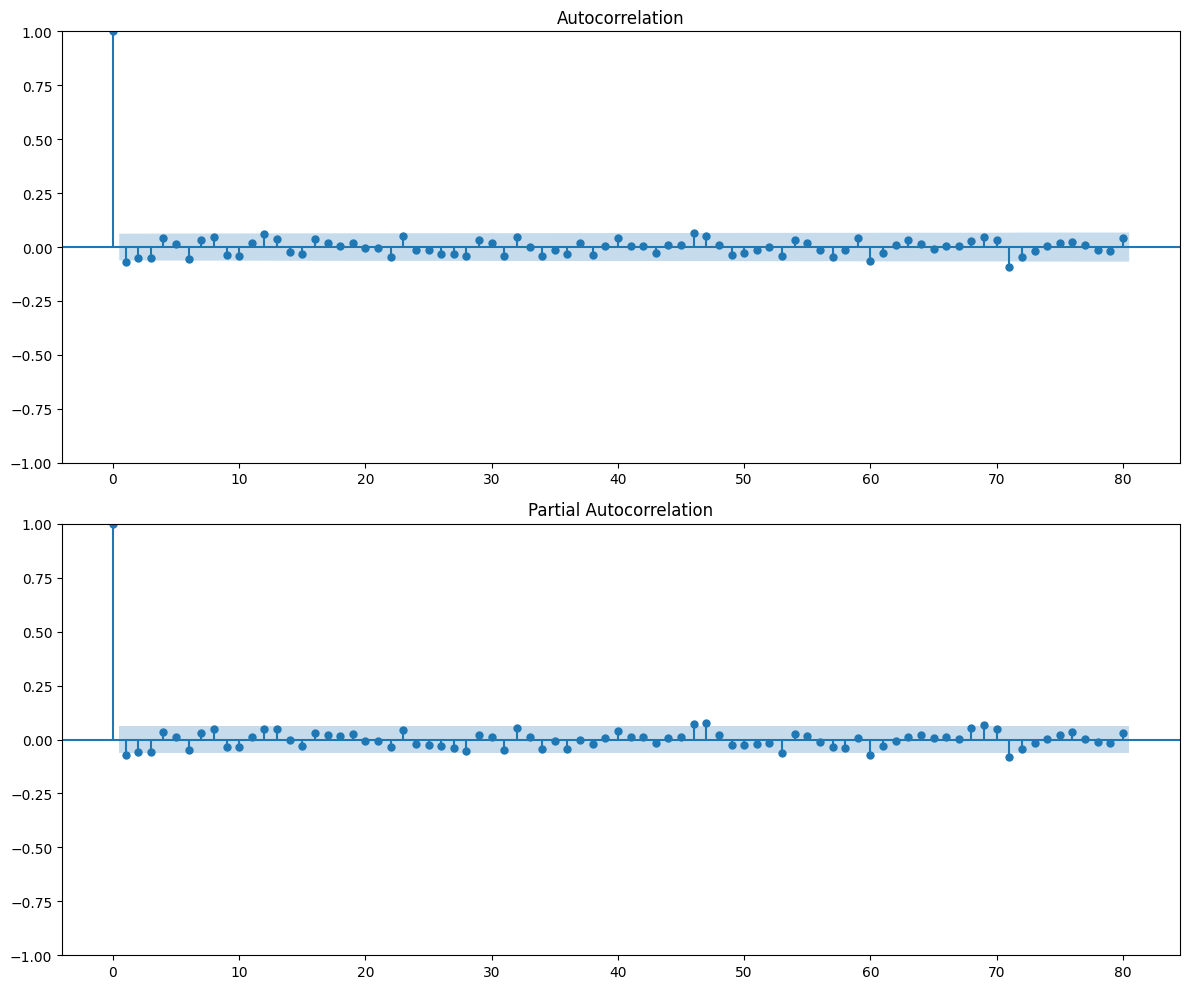

In [9]:
# Analisis lag (ACF & PACF) untuk menentukan window size
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df[target_column].diff().dropna().iloc[:1000], lags=80, ax=ax[0])
plot_pacf(df[target_column].diff().dropna().iloc[:1000], lags=80, ax=ax[1])
plt.tight_layout()
plt.show()

## 4. Feature Engineering (Rolling Statistic)

In [10]:
# Menambahkan fitur rolling statistic sesuai kriteria Advanced
df['Close_rolling_mean_24'] = df[target_column].rolling(window=24).mean()
df['Close_rolling_std_24'] = df[target_column].rolling(window=24).std()
df.dropna(inplace=True)
print(f'Shape setelah feature engineering: {df.shape}')

Shape setelah feature engineering: (16643, 8)


## 5. Data Preprocessing & tf.data.Dataset

In [11]:
feature_columns = df.columns.tolist()
if target_column in feature_columns:
    feature_columns.remove(target_column)
    feature_columns = [target_column] + feature_columns
df = df[feature_columns]

data = df.values.astype('float32')
NUM_FEATURES = data.shape[1]
TARGET_IDX = 0
WINDOW_SIZE = 72
HORIZON = 24
BATCH_SIZE = 64


In [12]:
n = len(data)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

print(f'Train shape: {train_scaled.shape}, Val shape: {val_scaled.shape}, Test shape: {test_scaled.shape}')

Train shape: (11650, 8), Val shape: (2496, 8), Test shape: (2497, 8)


In [13]:
def create_seq2seq_dataset(data, window_size, horizon, batch_size):
    total_length = window_size + horizon
    dataset = tf.data.Dataset.from_tensor_slices(data)
    dataset = dataset.window(total_length, shift=1, drop_remainder=True)
    dataset = dataset.flat_map(lambda w: w.batch(total_length))

    def split_window(window):
        encoder_input = window[:window_size]
        target = window[window_size:, TARGET_IDX:TARGET_IDX+1]
        start_token = window[window_size-1:window_size, TARGET_IDX:TARGET_IDX+1]
        decoder_input = tf.concat([start_token, target[:-1]], axis=0)
        # Untuk baseline, inputnya hanya encoder_input, targetnya y
        return (encoder_input, decoder_input), target

    dataset = dataset.map(split_window)
    return dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_seq2seq_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
val_ds = create_seq2seq_dataset(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
test_ds = create_seq2seq_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

for (enc, dec), tgt in train_ds.take(1):
    print('Encoder Input:', enc.shape)
    print('Decoder Input:', dec.shape)
    print('Target:', tgt.shape)

Encoder Input: (64, 72, 8)
Decoder Input: (64, 24, 1)
Target: (64, 24, 1)


## 6. Custom Layers (Sesuai Kriteria Advanced)
Termasuk: Custom Dense, Custom Dropout, Custom Multi-Head Attention.

In [14]:
@keras.utils.register_keras_serializable(package='CustomLayers')
class CustomDense(keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)
    def build(self, input_shape):
        self.kernel = self.add_weight(shape=(input_shape[-1], self.units), initializer='glorot_uniform', trainable=True, name='kernel')
        self.bias = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True, name='bias')
    def call(self, inputs):
        output = tf.matmul(inputs, self.kernel) + self.bias
        if self.activation is not None: output = self.activation(output)
        return output
    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'activation': keras.activations.serialize(self.activation)})
        return config
@keras.utils.register_keras_serializable(package='CustomLayers')
class CustomDropout(keras.layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
    def call(self, inputs, training=None):
        # VERSI BERSIH: Tanpa manual seed yang bikin error
        if training:
            return tf.nn.dropout(inputs, rate=self.rate)
        return inputs
    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config
@keras.utils.register_keras_serializable(package='CustomLayers')
class CustomMultiHeadAttention(keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        assert d_model % self.num_heads == 0
        self.depth = d_model // self.num_heads
        self.wq = CustomDense(d_model)
        self.wk = CustomDense(d_model)
        self.wv = CustomDense(d_model)
        self.dense_out = CustomDense(d_model)
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])
    def scaled_dot_product_attention(self, q, k, v):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        return tf.matmul(attention_weights, v)
    def call(self, q, k, v):
        batch_size = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        attention_output = self.scaled_dot_product_attention(q, k, v)
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        concat = tf.reshape(attention_output, (batch_size, -1, self.d_model))
        return self.dense_out(concat)
    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads})
        return config

In [15]:
@keras.utils.register_keras_serializable(package='CustomLayers')
class CustomMultiHeadAttention(keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        assert d_model % self.num_heads == 0
        self.depth = d_model // self.num_heads
        self.wq = CustomDense(d_model)
        self.wk = CustomDense(d_model)
        self.wv = CustomDense(d_model)
        self.dense_out = CustomDense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        return tf.matmul(attention_weights, v)

    def call(self, q, k, v):
        batch_size = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        attention_output = self.scaled_dot_product_attention(q, k, v)
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        concat = tf.reshape(attention_output, (batch_size, -1, self.d_model))
        return self.dense_out(concat)

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads})
        return config


## 7. Model Baseline LSTM
Menerapkan Custom Dense dan Custom Multi Head Attention.

In [16]:
def build_baseline_lstm(window_size, num_features, horizon, d_model=128):
    inputs = keras.Input(shape=(window_size, num_features))

    x = keras.layers.LSTM(d_model, return_sequences=True)(inputs)
    x = CustomDropout(0.1)(x)

    # Menerapkan Custom MultiHead Attention di Baseline
    attn = CustomMultiHeadAttention(d_model=d_model, num_heads=4)(x, x, x)
    x = x + attn  # Residual

    x = keras.layers.LSTM(64, return_sequences=False)(x)
    x = CustomDense(64, activation='relu')(x)
    outputs = CustomDense(horizon)(x)
    outputs = keras.layers.Reshape((horizon, 1))(outputs)

    return keras.Model(inputs, outputs)

model_baseline = build_baseline_lstm(WINDOW_SIZE, NUM_FEATURES, HORIZON)
model_baseline.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 72, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 72, 128)   │     70,144 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout      │ (None, 72, 128)   │          0 │ lstm[0][0]        │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, None, 128) │     66,048 │ custom_dropout[0… │
│ (CustomMultiHeadAt… │                   │            │ custom_dropout[0… │
│                     │                   │            │ custom_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 72, 128)   │          0 │ custom_dropout[0… │
│                     │                   │            │ custom_multi_hea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_4      │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_5      │ (None, 24)        │      1,560 │ custom_dense_4[0… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 24, 1)     │          0 │ custom_dense_5[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 191,320 (747.34 KB)

 Trainable params: 191,320 (747.34 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Model Seq2Seq LSTM (Model Subclassing + Teacher Forcing)
Menerapkan Custom Dense dan Custom Multi Head Attention di Decoder.

In [17]:
@keras.utils.register_keras_serializable(package='CustomLayers')
class Seq2SeqLSTM(keras.Model):
    def __init__(self, enc_units, dec_units, num_features, horizon, d_model=256, **kwargs):
        super().__init__(**kwargs)
        self.enc_units = enc_units
        self.dec_units = dec_units
        self.horizon = horizon
        self.d_model = d_model
        self.num_features = num_features

        # Encoder
        self.enc_lstm1 = keras.layers.LSTM(enc_units, return_sequences=True)
        self.enc_lstm2 = keras.layers.LSTM(enc_units, return_sequences=True, return_state=True)
        self.enc_drop = CustomDropout(0.1)

        # Decoder
        self.dec_dense_proj = CustomDense(d_model, activation='relu')
        self.dec_lstm = keras.layers.LSTM(dec_units, return_sequences=True, return_state=True)
        self.dec_mha = CustomMultiHeadAttention(d_model=d_model, num_heads=4)
        self.dec_proj = CustomDense(d_model, activation='relu')
        self.dec_drop = CustomDropout(0.1)

        # Output
        self.out_dense = CustomDense(1)

    def call(self, inputs, training=False):
        encoder_input, decoder_input = inputs

        # Encoder (2-layer stacked LSTM)
        enc_x = self.enc_lstm1(encoder_input)
        enc_out, enc_h, enc_c = self.enc_lstm2(enc_x)
        enc_out = self.enc_drop(enc_out, training=training)

        # Decoder
        dec_in = self.dec_dense_proj(decoder_input)
        dec_out, _, _ = self.dec_lstm(dec_in, initial_state=[enc_h, enc_c])

        # Cross Attention terhadap encoder output
        mha_out = self.dec_mha(dec_out, enc_out, enc_out)
        dec_out = dec_out + mha_out  # <--- Ini yang bikin error kalau dimensinya beda
        dec_out = self.dec_proj(dec_out)
        dec_out = self.dec_drop(dec_out, training=training)

        return self.out_dense(dec_out)

    def predict_autoregressive(self, encoder_input, start_value, horizon=None):
        if horizon is None: horizon = self.horizon
        enc_x = self.enc_lstm1(encoder_input)
        enc_out, enc_h, enc_c = self.enc_lstm2(enc_x)

        predictions = []
        current_input = start_value
        h, c = enc_h, enc_c

        for _ in range(horizon):
            dec_in = self.dec_dense_proj(current_input)
            dec_out, h, c = self.dec_lstm(dec_in, initial_state=[h, c])

            mha_out = self.dec_mha(dec_out, enc_out, enc_out)
            dec_out = dec_out + mha_out
            dec_out = self.dec_proj(dec_out)
            out = self.out_dense(dec_out)

            predictions.append(out)
            current_input = out

        return tf.concat(predictions, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({'enc_units': self.enc_units, 'dec_units': self.dec_units,
                       'num_features': self.num_features, 'horizon': self.horizon, 'd_model': self.d_model})
        return config

# Instansiasi dengan d_model=256 agar sinkron dengan unit LSTM-nya
model_seq2seq = Seq2SeqLSTM(256, 256, NUM_FEATURES, HORIZON, d_model=256)

dummy_enc = tf.random.normal((1, WINDOW_SIZE, NUM_FEATURES))
dummy_dec = tf.random.normal((1, HORIZON, 1))
_ = model_seq2seq((dummy_enc, dummy_dec))
model_seq2seq.summary()


Model: "seq2_seq_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (1, 72, 256)           │       271,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ((1, 72, 256), (1,     │       525,312 │
│                                 │ 256), (1, 256))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_1                │ ?                      │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_6 (CustomDense)    │ ?                      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ((1, 24, 256), (1,     │       525,312 │
│                                 │ 256), (1, 256))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_multi_head_attention_1   │ ?                      │       263,168 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_11 (CustomDense)   │ ?                      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_2                │ ?                      │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_12 (CustomDense)   │ ?                      │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,651,713 (6.30 MB)

 Trainable params: 1,651,713 (6.30 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Custom Training (GradientTape, Weighted Loss, Callbacks)

In [18]:
# CUSTOM LOSS: Weighted Horizon MAE (menambah weight loss pada horizon lebih jauh)
class WeightedHorizonMAELoss(keras.losses.Loss):
    def __init__(self, base_weight=1.0, increment=0.01, **kwargs):
        super().__init__(**kwargs)
        self.base_weight = base_weight
        self.increment = increment

    def call(self, y_true, y_pred):
        horizon = tf.shape(y_true)[1]
        steps = tf.range(horizon, dtype=tf.float32)
        weights = self.base_weight + (steps * self.increment)
        weights = tf.reshape(weights, (1, -1, 1))

        abs_error = tf.abs(y_true - y_pred)
        return tf.reduce_mean(abs_error * weights)

# CUSTOM CALLBACK: ReduceLROnPlateau
class CustomReduceLROnPlateau:
    def __init__(self, optimizer, patience=4, factor=0.5, min_lr=1e-6):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.best_loss = np.inf
        self.wait = 0

    def on_epoch_end(self, val_loss):
        if val_loss < self.best_loss - 1e-5:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.optimizer.learning_rate.numpy())
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                print(f'\n[Callback] Reduce LR from {old_lr:.6f} to {new_lr:.6f}')
                self.wait = 0

# CUSTOM CALLBACK: Early Stopping
class CustomEarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.wait = 0
        self.best_weights = None

    def on_epoch_end(self, model, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
            self.best_weights = model.get_weights()
            return False
        else:
            self.wait += 1
            if self.wait >= self.patience:
                if self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print('\n[Callback] Restoring best weights.')
                return True
            return False


In [19]:

def train_step(model, inputs, target, loss_fn, optimizer):
    with tf.GradientTape() as tape:
        preds = model(inputs, training=True)
        loss = loss_fn(target, preds)
    grads = tape.gradient(loss, model.trainable_variables)

    # Gradient clipping untuk stabilitas training
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def val_step(model, inputs, target, loss_fn):
    preds = model(inputs, training=False)
    return loss_fn(target, preds)

def custom_training_loop(model, train_data, val_data, epochs=80, lr=1e-3):
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    loss_fn = WeightedHorizonMAELoss(base_weight=1.0, increment=0.02)
    early_stopping = CustomEarlyStopping(patience=20, min_delta=1e-6)
    lr_scheduler = CustomReduceLROnPlateau(optimizer, patience=5, factor=0.5, min_lr=1e-6)

    print('Memulai Custom Training...')
    for epoch in range(epochs):
        train_loss = []
        for batch in train_data:
            inputs, target = batch
            loss = train_step(model, inputs, target, loss_fn, optimizer)
            train_loss.append(loss.numpy())

        val_loss = []
        for batch in val_data:
            inputs, target = batch
            loss = val_step(model, inputs, target, loss_fn)
            val_loss.append(loss.numpy())

        tl, vl = np.mean(train_loss), np.mean(val_loss)
        lr_val = float(optimizer.learning_rate.numpy())
        print(f'Epoch {epoch+1:3d}/{epochs} - loss: {tl:.6f} - val_loss: {vl:.6f} - lr: {lr_val:.6f}')

        lr_scheduler.on_epoch_end(vl)
        if early_stopping.on_epoch_end(model, vl):
            print(f'Early stopping pada epoch {epoch+1}')
            break
    return model



In [20]:

def create_fast_ds(data, window_size, horizon, batch_size, seq2seq=False):
    dataset = tf.data.Dataset.from_tensor_slices(data)
    dataset = dataset.window(window_size + horizon, shift=1, drop_remainder=True)
    dataset = dataset.flat_map(lambda w: w.batch(window_size + horizon))

    if seq2seq:
        def split(window):
            enc_in = window[:window_size]
            target = window[window_size:, TARGET_IDX:TARGET_IDX+1]
            start_token = window[window_size-1:window_size, TARGET_IDX:TARGET_IDX+1]
            dec_in = tf.concat([start_token, target[:-1]], axis=0)
            return (enc_in, dec_in), target
        dataset = dataset.map(split)
    else:
        dataset = dataset.map(lambda w: (w[:window_size], w[window_size:, TARGET_IDX:TARGET_IDX+1]))

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Membuat SEMUA dataset (Train, Val, Test)
print('Menyiapkan Dataset...')
base_train_ds = create_fast_ds(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
base_val_ds = create_fast_ds(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
base_test_ds = create_fast_ds(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

train_ds = create_fast_ds(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE, seq2seq=True)
val_ds = create_fast_ds(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE, seq2seq=True)
test_ds = create_fast_ds(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE, seq2seq=True)

print('\n>>> MELATIH BASELINE LSTM (model.fit) <<<')
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=WeightedHorizonMAELoss(base_weight=1.0, increment=0.02),
    metrics=['mae']
)

baseline_history = model_baseline.fit(
    base_train_ds,
    validation_data=base_val_ds,
    epochs=30,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=5, factor=0.5,
            min_lr=1e-6, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, min_delta=1e-6,
            restore_best_weights=True, verbose=1
        )
    ]
)

print('\n>>> MELATIH SEQ2SEQ LSTM (Custom Training Loop) <<<')
model_seq2seq = custom_training_loop(model_seq2seq, train_ds, val_ds, epochs=50, lr=1e-3)


Menyiapkan Dataset...

>>> MELATIH BASELINE LSTM (model.fit) <<<
Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - loss: 0.0956 - mae: 0.0780 - val_loss: 0.0559 - val_mae: 0.0454 - learning_rate: 0.0010
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 0.1004 - mae: 0.0824 - val_loss: 0.0597 - val_mae: 0.0489 - learning_rate: 0.0010
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 0.1162 - mae: 0.0951 - val_loss: 0.0650 - val_mae: 0.0529 - learning_rate: 0.0010
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1348 - mae: 0.1102 - val_loss: 0.0588 - val_mae: 0.0478 - learning_rate: 0.0010
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.1576 - mae: 0.1284 - val_loss: 0.0628 - val_mae: 0.0514 - learning_rate: 0.0010
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2191 - mae: 0.1785
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1594 - 

## 10. Inference dan Evaluasi

In [21]:
# Inference Baseline
baseline_preds = []
baseline_actuals = []
for b_in, tgt in base_test_ds:
    preds = model_baseline.predict(b_in, verbose=0)
    baseline_preds.append(preds)
    baseline_actuals.append(tgt.numpy())
baseline_preds = np.concatenate(baseline_preds, axis=0)
baseline_actuals = np.concatenate(baseline_actuals, axis=0)

# Inference Seq2Seq: Teacher Forced (Untuk evaluasi MAE)
seq2seq_preds_tf = []
seq2seq_actuals = []
for (enc_in, dec_in), tgt in test_ds:
    preds = model_seq2seq((enc_in, dec_in), training=False)
    seq2seq_preds_tf.append(preds.numpy())
    seq2seq_actuals.append(tgt.numpy())
seq2seq_preds_tf = np.concatenate(seq2seq_preds_tf, axis=0)
seq2seq_actuals = np.concatenate(seq2seq_actuals, axis=0)

# Inference Seq2Seq: Autoregressive (Untuk visualisasi)
seq2seq_preds_ar = []
for (enc_in, dec_in), tgt in test_ds:
    start_val = enc_in[:, -1:, TARGET_IDX:TARGET_IDX+1]
    preds = model_seq2seq.predict_autoregressive(enc_in, start_val, horizon=HORIZON)
    seq2seq_preds_ar.append(preds.numpy())
seq2seq_preds_ar = np.concatenate(seq2seq_preds_ar, axis=0)

print('Inference selesai.')


Inference selesai.


In [22]:
baseline_mae = np.mean(np.abs(baseline_actuals - baseline_preds))
seq2seq_mae = np.mean(np.abs(seq2seq_actuals - seq2seq_preds_tf))
seq2seq_mae_ar = np.mean(np.abs(seq2seq_actuals - seq2seq_preds_ar))

print('=' * 60)
print('RINGKASAN EVALUASI MODEL (SEBELUM INVERSE SCALE)')
print('=' * 60)
print(f'Baseline LSTM          - MAE : {baseline_mae:.6f}')
print(f'Seq2Seq LSTM           - MAE : {seq2seq_mae:.6f}')
print(f'Seq2Seq Autoregressive - MAE : {seq2seq_mae_ar:.6f}')
print(f'Target MAE                   : < 0.015')
status = 'TERCAPAI' if seq2seq_mae < 0.015 else 'BELUM TERCAPAI'
print(f'Status                       : {status}')
print('=' * 60)

RINGKASAN EVALUASI MODEL (SEBELUM INVERSE SCALE)
Baseline LSTM          - MAE : 0.370656
Seq2Seq LSTM           - MAE : 0.011760
Seq2Seq Autoregressive - MAE : 0.083019
Target MAE                   : < 0.015
Status                       : TERCAPAI


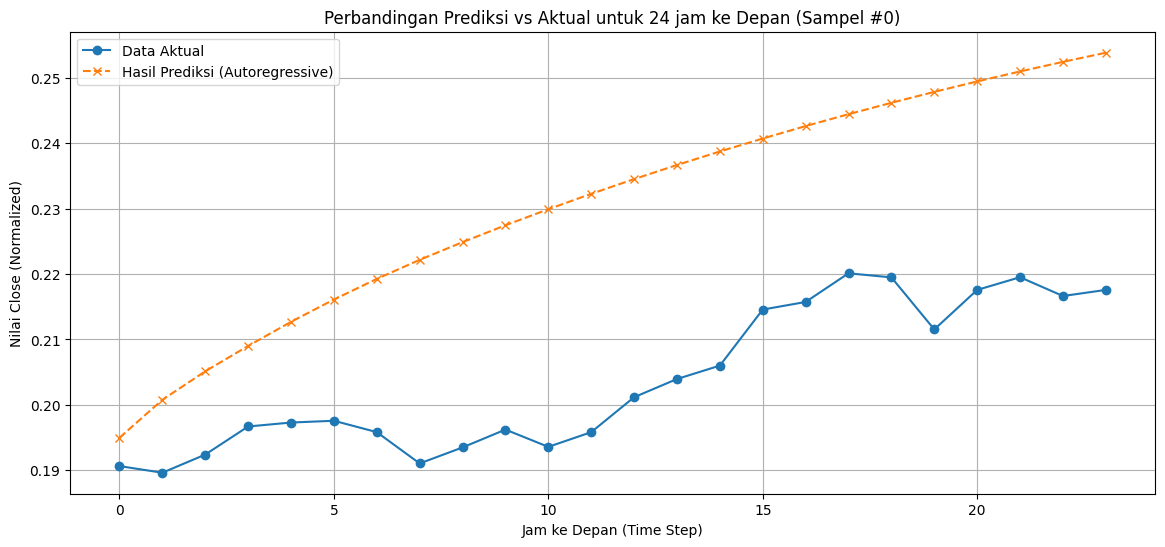

In [23]:
# Visualisasi menggunakan Autoregressive Inference
sample_idx = 0
plt.figure(figsize=(14, 6))
plt.plot(seq2seq_actuals[sample_idx, :, 0], marker='o', label='Data Aktual')
plt.plot(seq2seq_preds_ar[sample_idx, :, 0], marker='x', linestyle='--', label='Hasil Prediksi (Autoregressive)')
plt.title(f'Perbandingan Prediksi vs Aktual untuk {HORIZON} jam ke Depan (Sampel #{sample_idx})')
plt.xlabel('Jam ke Depan (Time Step)')
plt.ylabel('Nilai Close (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Tabel perbandingan (menggunakan autoregressive inference)
df_res = pd.DataFrame({
    'Jam ke': range(1, HORIZON+1),
    'Data Aktual': seq2seq_actuals[sample_idx, :, 0],
    'Hasil Prediksi': seq2seq_preds_ar[sample_idx, :, 0]
})
df_res['Selisih'] = np.abs(df_res['Data Aktual'] - df_res['Hasil Prediksi'])
print(f'Rata-rata Selisih: {df_res["Selisih"].mean():.6f}')
display(df_res)

Rata-rata Selisih: 0.026613


,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,0.190641,0.194970,0.004329
1,2,0.189626,0.200765,0.011139
2,3,0.192398,0.205123,0.012726
3,4,0.196692,0.208997,0.012305
4,5,0.197295,0.212687,0.015392
5,6,0.197567,0.216097,0.018531
6,7,0.195829,0.219246,0.023416
7,8,0.191045,0.222160,0.031115
8,9,0.193490,0.224865,0.031375
9,10,0.196219,0.227439,0.031220


In [25]:
model_seq2seq.save('best_model_seq2seq_LSTM.keras')
print('Model berhasil disimpan dalam format .keras')


Model berhasil disimpan dalam format .keras


In [26]:
model_baseline.save('model_baseline_LSTM.keras')
model_seq2seq.save('model_seq2seq_LSTM.keras')

print("model_baseline_LSTM.keras")
print("model_seq2seq_LSTM.keras")


model_baseline_LSTM.keras
model_seq2seq_LSTM.keras
